In [44]:
# !pip install rocketpy

In [1]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import datetime
import pandas as pd
import numpy as np
from rocketpy import SolidMotor
from rocketpy import Rocket

In [2]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [3]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)

In [4]:
tomorrow = datetime.date.today() + datetime.timedelta(days=1)
env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12))

In [5]:
# GFS  Global Forecast System
env.set_atmospheric_model(type="Forecast", file="GFS")


Gravity Details

Acceleration of gravity at surface level:    9.7861 m/s²
Acceleration of gravity at  79.050 km (ASL): 9.5480 m/s²


Launch Site Details

Launch Date: 2026-07-23 12:00:00 UTC
Launch Site Latitude: -21.94305°
Launch Site Longitude: -48.95409°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 91457.82 W    7568202.63 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 475.6 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 79.050 km
Forecast Time Period: from 2026-07-15 00:00:00 to 2026-08-07 12:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From 90.0° to -90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 4.42 m/s
Surface Wind Direction: 112.11°
Surface Wind Heading: 292.11°
Surface Pressure: 96138.05 hPa
Surface Temperature: 293.49 K
Surface Air Density: 114.111 kg/m³
Surface Speed of Sound: 343.43 m/s


Earth Model Details

Earth Radius at Laun

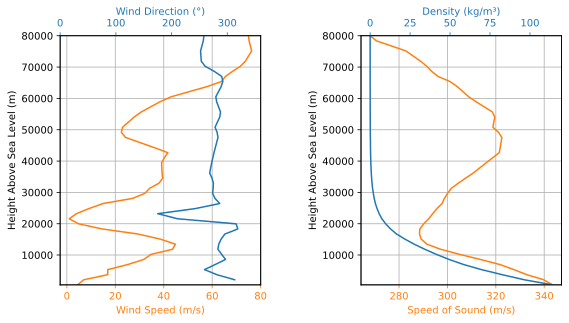

In [6]:
env.info()

In [7]:
# Read the motor CSV file
motor_data = pd.read_csv("motor_data.csv")

# Print column names to diagnose
print("DataFrame columns:", motor_data.columns)

# Drop the 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in motor_data.columns:
    motor_data = motor_data.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")
    print("Updated DataFrame columns:", motor_data.columns)

# Check for duplicate time values in the first column and remove them
if motor_data.iloc[:, 0].duplicated().any():
    print("Duplicate time values found in the thrust curve data. Removing duplicates.")
    motor_data = motor_data.drop_duplicates(subset=[motor_data.columns[0]])

# Select only the 'Time(s)' and 'Thrust(N)' columns and get the values as a NumPy array
thrust_source_array = motor_data[['Time(s)', 'Thrust(N)']].values

# Now, use the NumPy array as the thrust source to initialize SolidMotor
SRmotor = SolidMotor(
    thrust_source=thrust_source_array, # Use the NumPy array
    dry_mass= 0.85601,
    dry_inertia=(0.00001932937824, 0.00001932937909, 0.00000038491070),
    nozzle_radius=0.014885,
    grain_number=2,
    grain_density=1750,
    grain_outer_radius=0.022,
    grain_initial_inner_radius=0.0075,
    grain_initial_height=0.175,
    grain_separation=0,
    grains_center_of_mass_position=0.2,
    center_of_dry_mass_position=0.24,
    nozzle_position=0,
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=0.0070,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

print("\nSolidMotor initialized successfully!")

DataFrame columns: Index(['Time(s)', 'Thrust(N)'], dtype='str')

SolidMotor initialized successfully!


Nozzle Details
Nozzle Radius: 0.014885 m
Nozzle Throat Radius: 0.007 m

Grain Details
Number of Grains: 2
Grain Spacing: 0 m
Grain Density: 1750 kg/m3
Grain Outer Radius: 0.022 m
Grain Inner Radius: 0.0075 m
Grain Height: 0.175 m
Grain Volume: 0.000 m3
Grain Mass: 0.412 kg

Motor Details
Total Burning Time: 2.6259999999999764 s
Total Propellant Mass: 0.823 kg
Structural Mass Ratio: 0.510
Average Propellant Exhaust Velocity: 966.355 m/s
Average Thrust: 302.892 N
Maximum Thrust: 628.31248884 N at 0.9089999999999918 s after ignition.
Total Impulse: 795.395 Ns



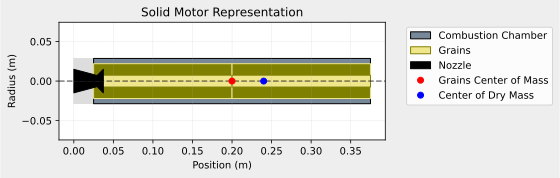

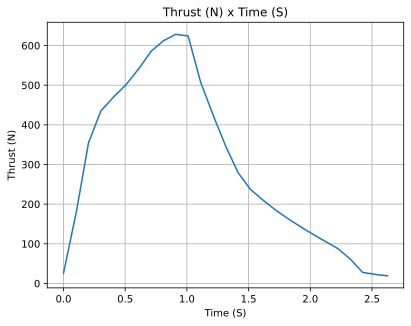

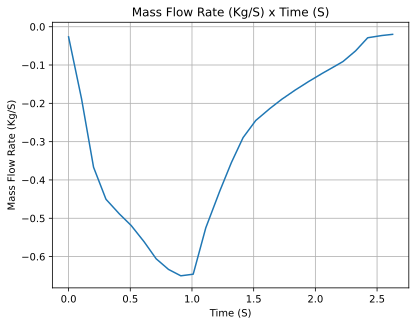

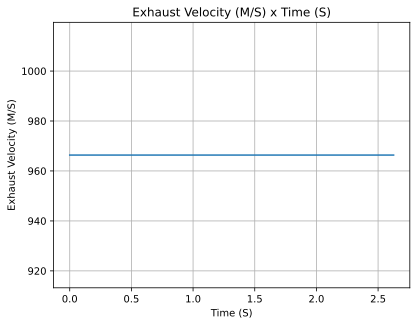

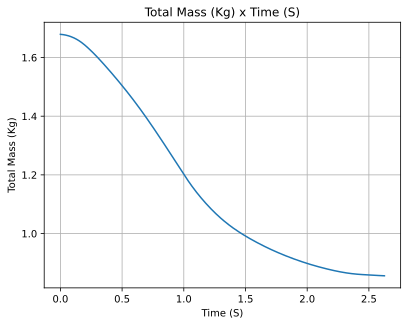

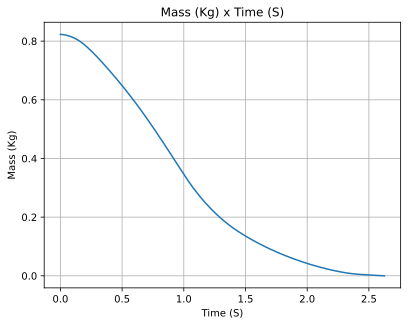

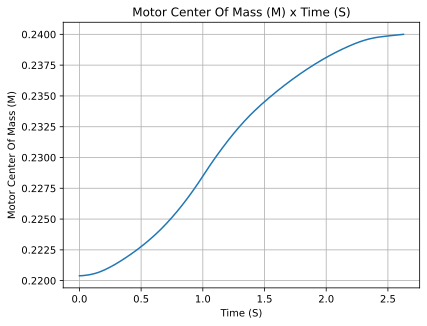

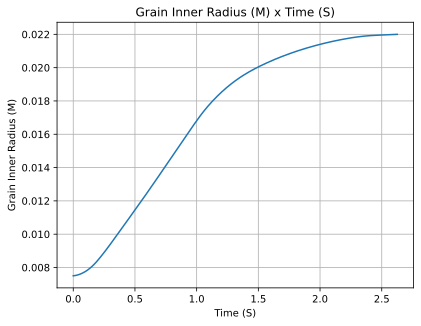

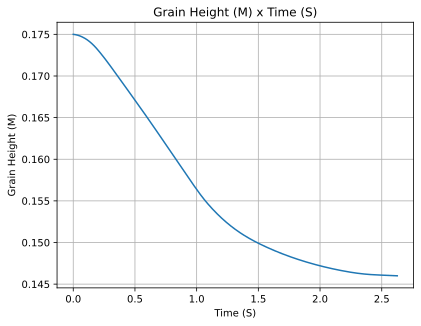

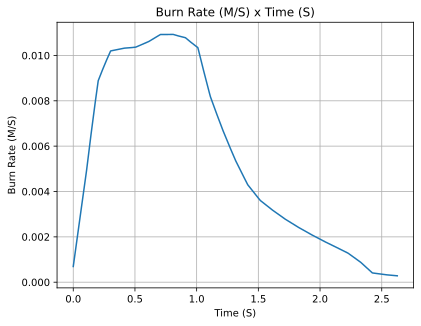

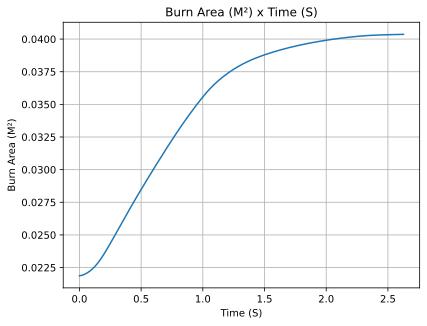

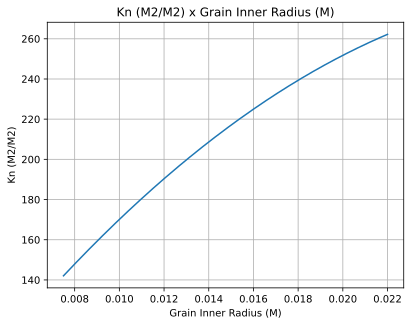

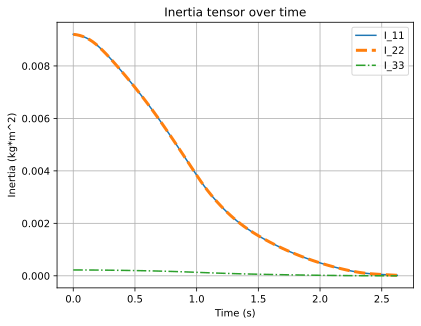

In [8]:
SRmotor.all_info()

In [9]:
# Function to read and process drag curve CSVs
def load_drag_curve(filepath):
    # Ler com separador ';' e decimal '.' (os arquivos usam ponto como separador decimal)
    drag_data = pd.read_csv(filepath, delimiter=';', skipinitialspace=True, header=None, decimal='.')

    # Remover colunas totalmente vazias (por exemplo linhas terminando com ';;')
    drag_data.dropna(axis=1, how='all', inplace=True)

    # Garantir pelo menos duas colunas
    if drag_data.shape[1] < 2:
        raise ValueError(f"Drag curve file {filepath} does not contain enough columns (expected at least 2).")

    # Usar apenas as duas primeiras colunas (Mach, Cd)
    drag_data = drag_data.iloc[:, :2]

    # Converter para numérico, coerindo erros para NaN
    drag_data = drag_data.apply(pd.to_numeric, errors='coerce')

    # Remover linhas com NaN resultantes da conversão
    drag_data.dropna(inplace=True)

    # Converter para array NumPy
    drag_array = drag_data.values

    # Remover linhas duplicadas
    drag_array = np.unique(drag_array, axis=0)

    # Ordenar por Mach (primeira coluna)
    drag_array = drag_array[drag_array[:, 0].argsort()]

    # Pequeno jitter para evitar colinearidade exata (só se tiver mais de 1 ponto)
    if drag_array.shape[0] > 1:
        jitter_amount = 1e-9 * (drag_array.max(axis=0) - drag_array.min(axis=0))
        # proteger contra jitter 0
        j0 = jitter_amount[0] if jitter_amount[0] != 0 else 1e-12
        j1 = jitter_amount[1] if jitter_amount[1] != 0 else 1e-12
        drag_array[:, 0] = drag_array[:, 0] + np.random.randn(drag_array.shape[0]) * j0
        drag_array[:, 1] = drag_array[:, 1] + np.random.randn(drag_array.shape[0]) * j1

    return drag_array

# Load and process drag curve data
power_off_drag_array = load_drag_curve("poweroffdragcurve.csv")
power_on_drag_array = load_drag_curve("powerondragcurve.csv")

print('power_off_drag_array shape:', power_off_drag_array.shape)
print('power_on_drag_array shape:', power_on_drag_array.shape)

# Salvar arrays processados em CSVs temporários para compatibilidade com Rocket
import os
power_off_path = "poweroff_processed.csv"
power_on_path = "poweron_processed.csv"

pd.DataFrame(power_off_drag_array).to_csv(power_off_path, index=False, header=False)
pd.DataFrame(power_on_drag_array).to_csv(power_on_path, index=False, header=False)

SRrocket = Rocket(
    radius = 0.038,
    mass=3.275,
    inertia=(2281370.34*(10**-9), 474090509.51*(10**-9), 474109826.94*(10**-9)),
    power_off_drag=power_off_path,
    power_on_drag=power_on_path,
    center_of_mass_without_motor=0.735,
    coordinate_system_orientation="nose_to_tail",
)

print("Rocket object created successfully!")


power_off_drag_array shape: (1174, 2)
power_on_drag_array shape: (55, 2)
Rocket object created successfully!


In [10]:
SRrocket.add_motor(SRmotor, position=1.5)

In [11]:
nose_cone = SRrocket.add_nose(
    length=0.197, kind="Ogive", position=0
)

aletas = SRrocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.10,
    tip_chord=0.047,
    span=0.057,
    position=1.395,
    cant_angle=58.99,
)



In [12]:
main = SRrocket.add_parachute(
    name="main",
    cd_s=1.5,
    trigger=750,      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    radius=0.6,
    noise=(0, 8.3, 0.5),
)


In [13]:
rail_buttons = SRrocket.set_rail_buttons(
    upper_button_position=0.385,
    lower_button_position=1.08,
    angular_position=45,
)

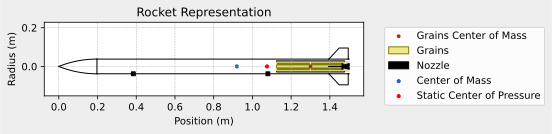

In [14]:
SRrocket.draw()

In [15]:
SRrocket.info()


Inertia Details

Rocket Mass: 3.275 kg (without motor)
Rocket Dry Mass: 4.131 kg (with unloaded motor)
Rocket Loaded Mass: 4.954 kg
Rocket Structural Mass Ratio: 0.834
Rocket Inertia (with unloaded motor) 11: 0.189 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.661 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.474 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.038 m
Rocket Frontal Area: 0.004536 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.109 m
Rocket Center of Dry Mass - Nozzle Exit: 0.656 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.456 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.076 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 5.441/rad

Center of Pressure

Nose Co

In [16]:
test_flight = Flight(
    rocket=SRrocket, environment=env, rail_length=4, inclination=85, heading=0, verbose=True)

KeyboardInterrupt: 

In [ ]:
SRrocket.plots.static_margin()

In [ ]:
test_flight.info()

In [ ]:
test_flight.plots

In [ ]:
test_flight.plots.trajectory_3d()

In [ ]:
test_flight.plots.linear_kinematics_data()

In [ ]:
test_flight.prints.apogee_conditions()

In [ ]:
test_flight.plots.aerodynamic_forces()

In [ ]:
test_flight.plots.rail_buttons_forces()